In [1]:
# Spatial Data EDA on Crop Production India
import pandas as pd
import geopandas as gpd
from libpysal.weights import Queen
from esda.moran import Moran
import matplotlib.pyplot as plt
from fuzzywuzzy import process

# Load crop production data
crop_df = pd.read_csv('Crop_Production_data.csv')

# ['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Area', 'Production']

crop_df.head()


d:\pywork\.venv\Lib\site-packages\fuzzywuzzy\fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,ANDAMAN AND NICOBAR,NICOBAR ISLANDS,2000,Kharif,Arecanut,1254.0,2000.0
1,ANDAMAN AND NICOBAR,NICOBAR ISLANDS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,ANDAMAN AND NICOBAR,NICOBAR ISLANDS,2000,Kharif,Rice,102.0,321.0
3,ANDAMAN AND NICOBAR,NICOBAR ISLANDS,2000,Whole Year,Banana,176.0,641.0
4,ANDAMAN AND NICOBAR,NICOBAR ISLANDS,2000,Whole Year,Cashewnut,720.0,165.0


In [ ]:
## Data Cleaning and Pre-Processing:

# Load India districts shapefile (replace with your path)
gdf = gpd.read_file("map\DISTRICT_BOUNDARY_Corrected.shp")
states_gdf = gpd.read_file("map\STATE_BOUNDARY_Corrected.shp")

# Clean names in both datasets
def clean_names(df, col):
    return df[col].str.strip().str.title()

crop_df['State_Name'] = crop_df['State_Name'].replace('ANDAMAN AND NICOBAR', 'ANDAMAN & NICOBAR')
crop_df['State_Name'] = crop_df['State_Name'].replace('Dadra and Nagar Haveli', 'DADRA & NAGAR HAVELI & DAMAN & DIU')

crop_df["District_Name"] = crop_df["District_Name"].replace('ALLAHABAD', 'PRAYAGRAJ')
crop_df["District_Name"] = crop_df["District_Name"].replace('FAIZABAD', 'AYODHYA')
crop_df["District_Name"] = crop_df["District_Name"].replace('GULBARGA', 'KALABURAGI')
crop_df["District_Name"] = crop_df["District_Name"].replace('MYSORE', 'MYSURU')
crop_df["District_Name"] = crop_df["District_Name"].replace('BANGALORE', 'BENGALURU URBAN')
crop_df["District_Name"] = crop_df["District_Name"].replace('BELGAUM', 'BELAGAVI')


districts_to_update = ['LEH (LADAKH)', 'KARGIL']  

# df.loc[condition, 'state'] = 'State Name to Replace'
crop_df.loc[(crop_df['State_Name'] == 'JAMMU AND KASHMIR') & (crop_df['District_Name'].isin(districts_to_update)), 'State_Name'] = 'LADAKH'


crop_df['State_Name'] = clean_names(crop_df, 'State_Name')
crop_df['District_Name'] = clean_names(crop_df, 'District_Name')
gdf['ST_NM'] = clean_names(gdf, 'STATE')        # Replace 'ST_NM' with state column name
gdf['DISTRICT'] = clean_names(gdf, 'District')  # Replace 'DISTRICT' with district column name


#['STATE','District']
gdf.head()

#crop_df.head()

,District,STATE,REMARKS,State_LGD,DISTRICT_L,Shape_Leng,Shape_Area,geometry,ST_NM,DISTRICT
0,MORBI,GUJARAT,None,24,673,539476.764723,4.791280e+09,"POLYGON ((3108952.09 3942577.01, 3109009.987 3...",Gujarat,Morbi
1,AHMEDABAD,GUJARAT,None,24,438,857254.094647,6.966374e+09,"POLYGON ((3193179.891 3920207.621, 3192925.978...",Gujarat,Ahmedabad
2,ANAND,GUJARAT,None,24,440,393046.690523,3.054307e+09,"POLYGON ((3297696.184 3879979.348, 3297775.311...",Gujarat,Anand
3,DEVBHUMI DWARKA,GUJARAT,None,24,674,661732.986530,4.002784e+09,"MULTIPOLYGON (((2924145.687 3865429.524, 29241...",Gujarat,Devbhumi Dwarka
4,JAMNAGAR,GUJARAT,None,24,447,737428.071884,5.694271e+09,"MULTIPOLYGON (((3044918.968 3859136.847, 30448...",Gujarat,Jamnagar


In [ ]:
# Ref: i) https://www.datacamp.com/tutorial/fuzzy-string-python
#      ii) https://pathindependence.wordpress.com/2015/10/31/tutorial-fuzzywuzzy-string-matching-in-python-improving-merge-accuracy-across-data-products-and-naming-conventions/

## Identify Mismatches in Shap file Naming:
# Get unique state-district pairs from both datasets
df_districts = crop_df.groupby(['State_Name', 'District_Name']).size().reset_index()
shp_districts = gdf.groupby(['ST_NM', 'DISTRICT']).size().reset_index()

# Find mismatches
mismatches = []
for idx, row in df_districts.iterrows():
    state = row['State_Name']
    district = row['District_Name']
    
    # Get matching districts from shapefile for this state
    shp_districts_for_state = shp_districts[shp_districts['ST_NM'] == state]['DISTRICT'].tolist()
    
    if district not in shp_districts_for_state:
        mismatches.append({
            'State': state,
            'CSV_District': district,
            'Shapefile_Districts': shp_districts_for_state
        })

## Fuzzy Match Correction Suggestions ::

# Generate correction map
correction_map = {}
print("Suggested Corrections:")
for mismatch in mismatches:
    state = mismatch['State']
    csv_district = mismatch['CSV_District']
    candidates = mismatch['Shapefile_Districts']
    
    if candidates:
        match, score = process.extractOne(csv_district, candidates)
        if score > 70:  # 85 was giving much more mismatch
            # Add to correction map
            if state not in correction_map:
                correction_map[state] = {}
            correction_map[state][csv_district] = match
            
            # Print Correction :
            #print(f"{state}:")
            #print(f"  '{csv_district}' → '{match}' (confidence: {score}%)")

# Print the generated correction map
#print("\n Auto  Correction Map:")
#print(correction_map)        

# Update the dataframe with corrections
crop_df['District_Name'] = crop_df.apply(
    lambda x: correction_map.get(x['State_Name'], {}).get(x['District_Name'], x['District_Name']), 
    axis=1
)


Suggested Corrections:


<Figure size 1000x800 with 0 Axes>

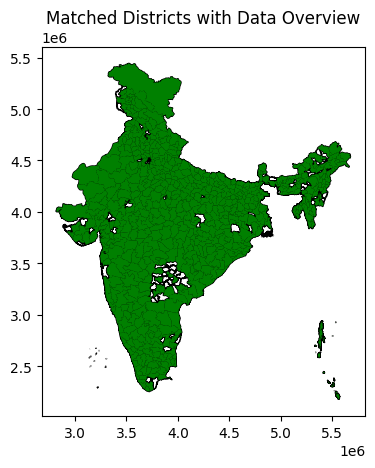

In [ ]:
# CSV data structure
district_counts = crop_df.groupby(['State_Name','District_Name'])['District_Name'].value_counts().reset_index()
district_counts.columns = ['State_Name','District_Name','Count']

# SHAP file structure
gdf["District"] = gdf["District"].str.strip().str.upper()
gdf["STATE"] = gdf["STATE"].str.strip().str.upper()  # State column in shapefile

# Prepare to merge data:
district_counts['State_Name'] = district_counts['State_Name'].str.upper()
district_counts['District_Name'] = district_counts['District_Name'].str.strip().str.upper()

# merge data :
merged_data = pd.merge(gdf,district_counts,how='left',left_on=['STATE','District'],right_on=['State_Name','District_Name'])
merged_data.drop(['State_Name','District_Name'],inplace=True,axis=1)


# Copy District with no data
merge_struct = merged_data[merged_data['Count'].isna()]


# Drop the districts with no count/data available:
merged_data.dropna(subset=['Count'], inplace=True)

ax = plt.figure(figsize=(10, 8))
# Plot matched districts
#fig, ax = plt.subplots(1, 1, figsize=(10, 10))
base = gdf.plot(color='white', edgecolor='black')
merged_data.plot(ax=base, color='green', markersize=0.1)

# Overlay state boundaries
#states_gdf.boundary.plot(ax=base, color='black', linewidth=1.2)

plt.title('Matched Districts with Data Overview')
plt.show()


C:\Users\Manish\AppData\Local\Temp\ipykernel_25904\395914082.py:21: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(merged)
d:\pywork\.venv\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 5 disconnected components.
 There are 4 islands with ids: 237, 273, 277, 355.
  W.__init__(self, neighbors, ids=ids, **kw)


('WARNING: ', 237, ' is an island (no neighbors)')
('WARNING: ', 273, ' is an island (no neighbors)')
('WARNING: ', 277, ' is an island (no neighbors)')
('WARNING: ', 355, ' is an island (no neighbors)')
Moran's I: 0.3900751998679436
P-value: 2.136022153072154e-66


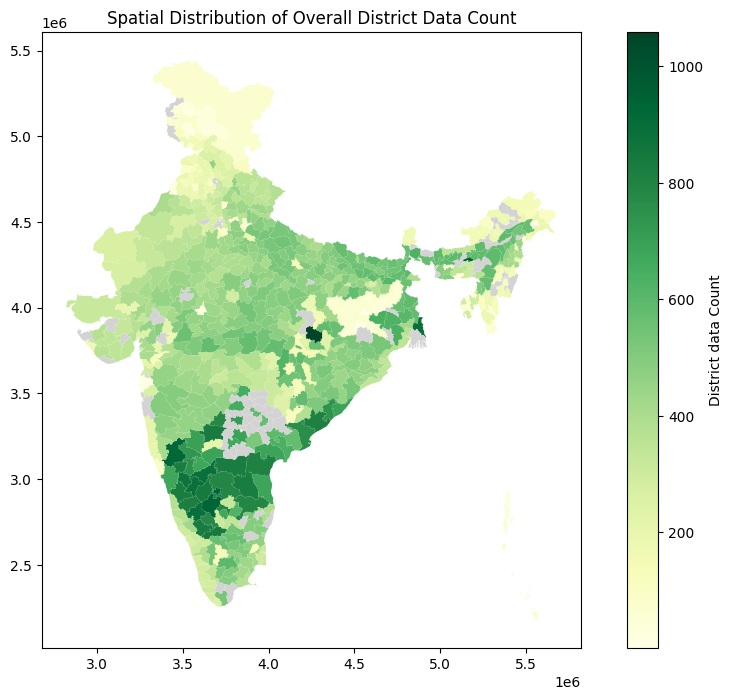

In [6]:
#ref: https://darribas.org/gds_scipy16/ipynb_md/04_esda.html

# Aggregate data count/occurance by district (example for latest year)
latest_year = crop_df['Crop_Year'].max()
year = 1997

# District data count :
district_counts = crop_df.groupby(['State_Name','District_Name'])['District_Name'].value_counts().reset_index()
district_counts.columns = ['State_Name','District_Name','Count']

# district_counts = crop_df[crop_df['Crop_Year'] == year].groupby(['State_Name','District_Name'])['District_Name'].value_counts().reset_index()
# district_counts.columns = ['State_Name','District_Name','Count']

# Clean district names if needed 
district_counts['District_Name'] = district_counts['District_Name'].str.title()

# Merge production data with spatial data
merged = gdf.merge(district_counts, how='left', left_on='DISTRICT', right_on='District_Name')

# Create spatial weights matrix
w = Queen.from_dataframe(merged)

# Calculate Moran's I for spatial autocorrelation
moran = Moran(merged['Count'].fillna(0), w)

print(f"Moran's I: {moran.I}")
print(f"P-value: {moran.p_norm}")

# Visualize spatial autocorrelation
fig, ax = plt.subplots(figsize=(12, 8))

# Overlay state boundaries
#states_gdf.boundary.plot(ax=base, color='black', linewidth=1.0)

merged.plot(column='Count', ax=ax, legend=True,
           legend_kwds={'label': "District data Count"},
           cmap='YlGn', missing_kwds={'color': 'lightgrey'})



plt.title(f'Spatial Distribution of Overall District Data Count')
plt.show()

      



In [ ]:
# Sanity check for data picked:
result = district_counts.loc[(district_counts['State_Name'] == "KARNATAKA") & (district_counts['District_Name'] == "BENGALURU URBAN"), 'Count']

print(result.values)


C:\Users\Manish\AppData\Local\Temp\ipykernel_25904\2663488853.py:15: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(merged)
d:\pywork\.venv\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 5 disconnected components.
 There are 4 islands with ids: 231, 267, 271, 346.
  W.__init__(self, neighbors, ids=ids, **kw)


('WARNING: ', 231, ' is an island (no neighbors)')
('WARNING: ', 267, ' is an island (no neighbors)')
('WARNING: ', 271, ' is an island (no neighbors)')
('WARNING: ', 346, ' is an island (no neighbors)')
Moran's I: 0.3965635095722648
P-value: 8.135706583622637e-67


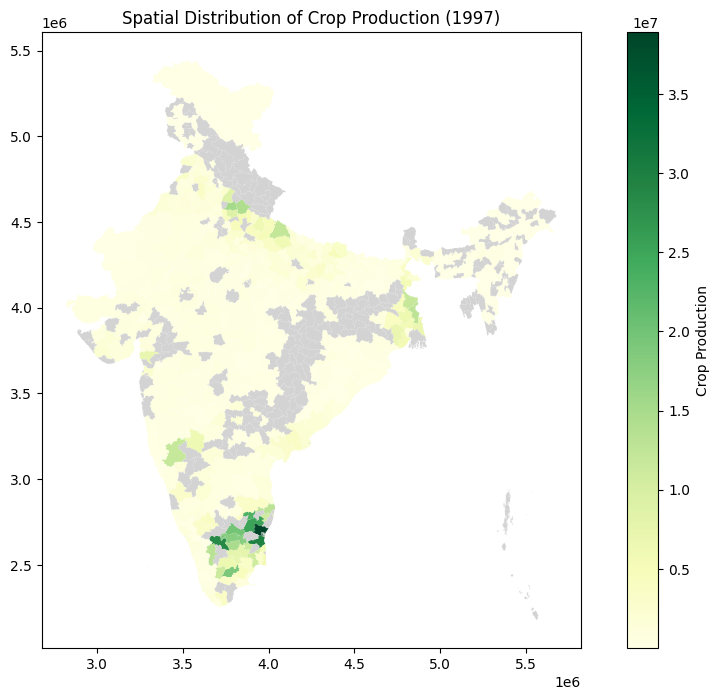

In [8]:
# Aggregate production by district (example for latest year)
latest_year = crop_df['Crop_Year'].max()
year = 1997
district_production = crop_df[crop_df['Crop_Year'] == year].groupby(['State_Name','District_Name'])['Production'].sum().reset_index()
district_production.columns = ['State_Name','District_Name','Production']


# Clean district names if needed (critical step)
district_production['District_Name'] = district_production['District_Name'].str.title()

# Merge production data with spatial data
merged = gdf.merge(district_production, how='left', left_on='DISTRICT', right_on='District_Name')

# Create spatial weights matrix
w = Queen.from_dataframe(merged)

# Calculate Moran's I for spatial autocorrelation
moran = Moran(merged['Production'].fillna(0), w)

print(f"Moran's I: {moran.I}")
print(f"P-value: {moran.p_norm}")

# Visualize spatial autocorrelation
fig, ax = plt.subplots(figsize=(12, 8))
merged.plot(column='Production', ax=ax, legend=True,
           legend_kwds={'label': "Crop Production"},
           cmap='YlGn', missing_kwds={'color': 'lightgrey'})

# Overlay state boundaries
#states_gdf.boundary.plot(ax=base, color='black', linewidth=1.2)

plt.title(f'Spatial Distribution of Crop Production ({year})')
plt.show()

In [ ]:
# Analyze production changes between seasons